<a href="https://colab.research.google.com/github/Andrea-24744/Procesos-Est-casticos-/blob/main/Matriz_Fundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ratón
####Resolver analíticamente y por simulación el siguiente ejercicio:


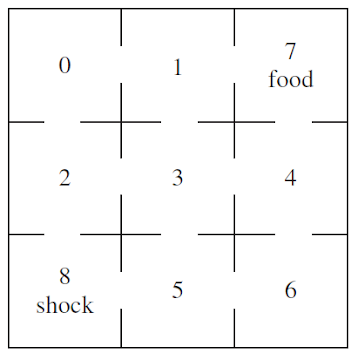



1.   *¿Cuál es la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida?*




Primeramente, se empleará la forma analítica, donde, de forma manual se determinó la matriz de transición correspondiente, siendo de la siguiente manera:

In [1]:
import sympy as sp
import numpy as np

A = sp.Matrix([   [0,sp.Rational(1,2),sp.Rational(1,2),0,0,0,0,0,0],
                  [sp.Rational(1,3),0,0,sp.Rational(1,3),0,0,0,sp.Rational(1,3),0],
                  [sp.Rational(1,3),0,0,sp.Rational(1,3),0,0,0,0,sp.Rational(1,3)],
                  [0,sp.Rational(1,4),sp.Rational(1,4),0,sp.Rational(1,4),sp.Rational(1,4),0,0,0],
                  [0,0,0,sp.Rational(1,3),0,0,sp.Rational(1,3),sp.Rational(1,3),0],
                  [0,0,0,sp.Rational(1,3),0,0,sp.Rational(1,3),0,sp.Rational(1,3)],
                  [0,0,0,0,sp.Rational(1,2),sp.Rational(1,2),0,0,0],
                  [0,0,0,0,0,0,0,1,0],
                  [0,0,0,0,0,0,0,0,1]  ])


In [2]:
sp.pprint(A)

⎡ 0   1/2  1/2   0    0    0    0    0    0 ⎤
⎢                                           ⎥
⎢1/3   0    0   1/3   0    0    0   1/3   0 ⎥
⎢                                           ⎥
⎢1/3   0    0   1/3   0    0    0    0   1/3⎥
⎢                                           ⎥
⎢ 0   1/4  1/4   0   1/4  1/4   0    0    0 ⎥
⎢                                           ⎥
⎢ 0    0    0   1/3   0    0   1/3  1/3   0 ⎥
⎢                                           ⎥
⎢ 0    0    0   1/3   0    0   1/3   0   1/3⎥
⎢                                           ⎥
⎢ 0    0    0    0   1/2  1/2   0    0    0 ⎥
⎢                                           ⎥
⎢ 0    0    0    0    0    0    0    1    0 ⎥
⎢                                           ⎥
⎣ 0    0    0    0    0    0    0    0    1 ⎦



> Notemos que la matriz ya está en su forma canónica, todos los primeros 7 estados corresponden a estados transitorios y los últimos dos son estados recurrentes (el último absorbente también)


> Por lo que solo tomaremos los estados transitorios para trabajar con la submatriz asociada a ellos, así como otra submatriz de estados recurrentes


In [3]:
# Convertimos los datos de la matriz a flotantes para poder operar correctamente
A = np.array(A, dtype=float)
Q = A[:7,:7] # Solo tomamos estados transitorios
R = A[:7,7:] # estados recurrentes

I = sp.eye(Q.shape[0]) # Identidad

N = (I - Q)
N = np.array(N, dtype=float) # Convertimos nuevamente a flotante para evitar errores


In [4]:
# Calculamos la inversa
N_inv = np.linalg.inv(N)
B_r = N_inv @ R

# Redondeamos
B_rounded = np.round(B_r, 3)
print(B_rounded)

[[0.5   0.5  ]
 [0.667 0.333]
 [0.333 0.667]
 [0.5   0.5  ]
 [0.667 0.333]
 [0.333 0.667]
 [0.5   0.5  ]]


Ahora de esta matriz resultante, nos interesa la situación de que iniciando en la casilla 0 el ratón alcance la comida, recordando que mi matriz representa $($transitorios$)×($absorbentes$)$, implica que las filas son los estados transitorios  $(0,1,2,3,4,5,6)$, y las columnas son los absorbentes $(7 , 8)$, por lo que estando en 0 la probabilidad de llegar a la comida $(7)$ será la entrada:

 ***$B_{0,0}$*** *fila 1 (estado 0), columna 1 (estado 7)*

In [5]:
print(B_rounded[0,0])

0.5


Otra forma de resolver el problema analíticamente consiste en plantear un sistema de ecuaciones lineales para las probabilidades de absorción.

A partir de las transiciones posibles entre estados, se construye un sistema de ecuaciones de la forma:

$$ Ax=b $$

donde $A$ representa la matriz de coeficientes asociada a las probabilidades de transición entre estados transitorios, y $b$ contiene las contribuciones de los estados absorbentes.



In [6]:
# Establecemos todos los caminos posibles, es decir,
# si estoy en cierta casilla a cuáles más puedo ir en un solo paso (todas mis “conexiones”)
import numpy as np

conectados = {
    0: [1,2],
    1: [0,3,7],   # 7 = comida
    2: [0,3,8],   # 8 = shock
    3: [1,2,4,5],
    4: [3,6,7],
    5: [3,6,8],
    6: [4,5]
}

# Estados transitorios
est_trans = [0,1,2,3,4,5,6]

# Número de estados transitorios
n = len(est_trans)

# Matriz del sistema
A = np.eye(n)

# Vector independiente
b = np.zeros(n)

# Recorre cada estado transitorio
for i, s in enumerate(est_trans):

    # Número de conexiones del estado actual
    deg = len(conectados[s])

    # Recorre cada posible transición desde el estado s
    for t in conectados[s]:

        # Si llega a comida
        if t == 7:

            # P(food)=1
            b[i] += 1/deg

        # Si llega a shock
        elif t == 8:

            # P(shock)=0
            pass

        # Si llega a otro estado transitorio
        else:

            # Posición del estado
            j = est_trans.index(t)

            # Construcción de la matriz
            A[i,j] -= 1/deg

# Resolver sistema
p = np.linalg.solve(A,b)

print("Probabilidades de llegar a comida:")
print(p)

print("\nProbabilidad empezando desde 0:")
print(f"{p[0]:.2f}")

Probabilidades de llegar a comida:
[0.5        0.66666667 0.33333333 0.5        0.66666667 0.33333333
 0.5       ]

Probabilidad empezando desde 0:
0.50


Luego, resolviendolo por simulación, queda de la siguiente manera:

In [7]:
import random


conectados = {
    0: [1,2],
    1: [0,3,7],   # 7 = comida
    2: [0,3,8],   # 8 = shock
    3: [1,2,4,5],
    4: [3,6,7],
    5: [3,6,8],
    6: [4,5]
}

# Contador de veces que el ratón llega a la comida
comida = 0

# Número de simulaciones
N = 10000

# Ciclo principal de simulación
for _ in range(N):

    # El ratón inicia en el estado 0
    estado = 0

    # Mientras no llegue a un estado absorbente
    while estado not in [7,8]:

        # Elige aleatoriamente uno de los caminos posibles
        estado = random.choice(conectados[estado])

    # Si terminó en comida, aumentar contador
    if estado == 7:
        comida += 1

# Probabilidad estimada
probabilidad = comida / N

print("Probabilidad aproximada de llegar a la comida:")
print(probabilidad)


Probabilidad aproximada de llegar a la comida:
0.5042


---
---

#Serpientes y escaleras
####Resolver analíticamente y por simulación el siguiente ejercicio:

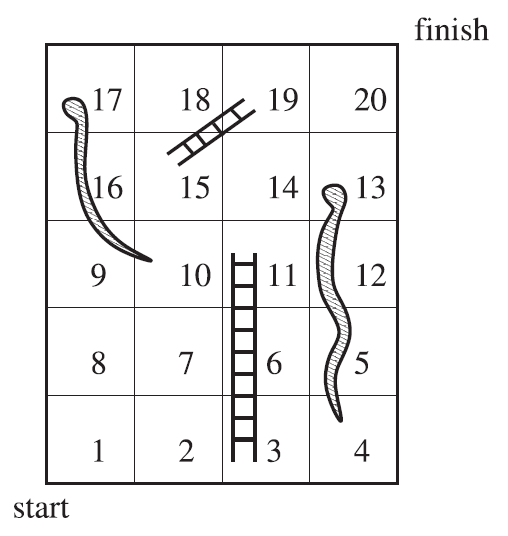

2. *¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?*

Primeramente, se empleará la forma analítica, donde, al tener varios estados se determinó la matriz de transición correspondiente de la siguiente forma:

In [8]:
import sympy as sp
import numpy as np
import pandas as pd

# Número total de estados del tablero
# Estados: 0,1,2,...,20
n_estados = 21

# Estado final (meta)
final = 20

# serpientes y escaleras
saltos = {
    3:11,
    15:19,
    13:4,
    17:9
}

# Función que calcula el movimiento del jugador
def mover(pos, dado):

    # Nueva posición después de lanzar el dado
    nueva = pos + dado

    # Si llega o supera la meta,
    # el jugador pasa al estado absorbente 20
    if nueva >= final:
        return final

    # Revisa si cayó en serpiente o escalera
    if nueva in saltos:
        nueva = saltos[nueva]

    return nueva

# Inicializa matriz de transición
P = np.zeros((n_estados, n_estados))

# Construcción de probabilidades de transición
for i in range(final):

    # Posibles resultados del dado
    for dado in range(1,7):

        # Estado al que se mueve
        j = mover(i,dado)

        # Cada resultado del dado tiene probabilidad 1/6
        P[i,j] += 1/6



# El estado final es absorbente
# Una vez que llega a 20 permanece ahí
P[final,final] = 1

# Es para lograr visualizar la matriz completa
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
df = pd.DataFrame([[str(x) for x in row] for row in P])

# Muestra la matriz redondeada
df = pd.DataFrame(np.round(P,3))

df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.0,0.167,0.167,0.0,0.167,0.167,0.167,0.000,0.000,0.000,0.000,0.167,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000
1,0.0,0.000,0.167,0.0,0.167,0.167,0.167,0.167,0.000,0.000,0.000,0.167,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000
2,0.0,0.000,0.000,0.0,0.167,0.167,0.167,0.167,0.167,0.000,0.000,0.167,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000
3,0.0,0.000,0.000,0.0,0.167,0.167,0.167,0.167,0.167,0.167,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000
4,0.0,0.000,0.000,0.0,0.000,0.167,0.167,0.167,0.167,0.167,0.167,0.000,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000
5,0.0,0.000,0.000,0.0,0.000,0.000,0.167,0.167,0.167,0.167,0.167,0.167,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000
6,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.167,0.167,0.167,0.167,0.167,0.167,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000
7,0.0,0.000,0.000,0.0,0.167,0.000,0.000,0.000,0.167,0.167,0.167,0.167,0.167,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000
8,0.0,0.000,0.000,0.0,0.167,0.000,0.000,0.000,0.000,0.167,0.167,0.167,0.167,0.0,0.167,0.0,0.000,0.0,0.000,0.000,0.000
9,0.0,0.000,0.000,0.0,0.167,0.000,0.000,0.000,0.000,0.000,0.167,0.167,0.167,0.0,0.167,0.0,0.000,0.0,0.000,0.167,0.000


> Notemos que la matriz de transición ya se encuentra organizada en forma canónica, debido a que los primeros estados corresponden a estados transitorios y el último estado corresponde al estado absorbente.

> Por esta razón, es posible trabajar directamente con las submatrices:
$Q = P_{(0:19,\;0:19)}$, la cual contiene únicamente las transiciones entre estados transitorios, y $R = P_{(0:19,\;20)}$ que contiene las probabilidades de transición desde los estados transitorios hacia el estado absorbente.



In [9]:
# Convertimos los datos de la matriz a flotantes para poder operar correctamente
P = np.array(P, dtype=float)
Q = P[:20,:20] # Solo tomamos estados transitorios
R = P[:20,20:] # estados recurrentes

I = sp.eye(Q.shape[0]) # Identidad

N = (I - Q)
N = np.array(N, dtype=float) # Convertimos nuevamente a flotante para evitar errores

In [10]:
# Calcular la inversa de N (NumPy)
N_inv = np.linalg.inv(N)
B_r = N_inv @ R

# Vector columna de unos, se utiliza porque al multiplicar:
# t = N * 1
# Obtienendo el número esperado de pasos antes de llegar al estado absorbente
ones = sp.ones(20,1)

t = N_inv @ ones # Tiempo esperado de absorción
sp.pprint(t)

⎡7.18273428099072⎤
⎢                ⎥
⎢7.01671609272013⎥
⎢                ⎥
⎢6.80678903806646⎥
⎢                ⎥
⎢6.86230416665619⎥
⎢                ⎥
⎢6.52612028488837⎥
⎢                ⎥
⎢6.24589340460019⎥
⎢                ⎥
⎢5.93635474279799⎥
⎢                ⎥
⎢6.02060696309662⎥
⎢                ⎥
⎢5.54722671014446⎥
⎢                ⎥
⎢4.89762289440954⎥
⎢                ⎥
⎢4.50901699428142⎥
⎢                ⎥
⎢4.56453212287115⎥
⎢                ⎥
⎢4.07912277198479⎥
⎢                ⎥
⎢3.1581027245034 ⎥
⎢                ⎥
⎢2.70694519243148⎥
⎢                ⎥
⎢2.54027852576482⎥
⎢                ⎥
⎢2.1773815935127 ⎥
⎢                ⎥
⎢1.36111111111111⎥
⎢                ⎥
⎢1.16666666666667⎥
⎢                ⎥
⎣      1.0       ⎦


La matriz $t$ contiene las probabilidades de alcanzar el estado absorbente iniciando desde cada estado transitorio. En este caso, como únicamente existe un estado absorbente (la casilla $20$), la matriz resultante tiene dimensión:
$(\text{transitorios}) \times (\text{absorbentes})$ es decir: $20 \times 1$

Por lo tanto, cada fila representa un estado transitorio $(0,1,2,\dots,19)$, mientras que la única columna representa la probabilidad de llegar al estado absorbente $20$.

Así, la probabilidad de terminar el juego (caer en casilla 20) iniciando desde el principio (estado $0$) corresponde a la entrada:

**$B_{0,0}$**, es decir, *fila 1 (estado 0) y columna 1 (estado absorbente 20).*

In [11]:
# Tiempo esperado iniciando desde el estado 0
print("El número promedio de tiradas necesarias para terminar el juego es ",t[0].evalf())

El número promedio de tiradas necesarias para terminar el juego es  7.18273428099072


Otra forma de resolver el problema analíticamente consiste en plantear un sistema de ecuaciones lineales para las probabilidades de absorción.

A partir de las transiciones posibles entre estados, se construye un sistema de ecuaciones de la forma:

$$ Ax=b $$

donde $A$ representa la matriz de coeficientes asociada a las probabilidades de transición entre estados transitorios, y $b$ contiene las contribuciones de los estados absorbentes.

In [13]:
import numpy as np

# Número total de estados del tablero
# Estados: 0,1,2,...,20
n_estados = 21

# Estado final (meta)
final = 20

# serpientes y escaleras
saltos = {
    3:11,
    15:19,
    13:4,
    17:9
}

# El estado 20 será absorbente
N = 20

# Matriz del sistema de ecuaciones
# iniciando como matriz identidad
A = np.eye(N)

# Vector independiente
# representa una tirada adicional del dado
b = np.ones(N)

# Recorre cada estado transitorio
for s in range(N):

    # Posibles resultados del dado
    for d in range(1, 7):

        # Nueva posición después del movimiento
        t = min(s + d, N)

        # Aplica serpiente o escalera si existe
        t = saltos.get(t, t)

        # Si todavía no llega al estado absorbente
        if t < N:

            # Construcción del sistema de ecuaciones
            # Se resta la probabilidad de transición
            A[s, t] -= 1/6

# Resolver el sistema:
E = np.linalg.solve(A, b)

# Mostrar el valor esperado iniciando desde 0
print("Valor esperado de tiradas:")
print(round(E[0], 6))

Valor esperado de tiradas:
7.182734


Luego, resolviendolo por simulación, queda de la siguiente manera:

In [19]:
import random
import numpy as np

# Número de simulaciones
simulaciones = 80000

# Estado final (meta)
final = 20

# serpientes y escaleras
jumps = {
    3: 11,
    15: 19,
    17: 9,
    13: 4
}

# Lista donde se almacenará
# el número de tiradas de cada partida
resultados = []

# Repite el juego muchas veces
for _ in range(simulaciones):

    # El jugador inicia en la casilla 0
    posicion = 0

    # Contador
    tiros = 0

    # Continua mientras no llegue a la meta
    while posicion < final:

        # Lanzamiento aleatorio del dado
        dado = random.randint(1,6)

        # Aumenta contador de tiradas
        tiros += 1

        # Avanza posiciones
        posicion += dado

        # Si supera la meta, termina en 20
        posicion = min(posicion, final)

        # Revisa serpiente o escalera
        if posicion in jumps:
            posicion = jumps[posicion]

    # Guarda cantidad de tiradas usadas
    resultados.append(tiros)

# Promedio de tiradas de todas las simulaciones
esperanza = np.mean(resultados)

print("Valor esperado aproximado de tiradas:")
print(round(esperanza,6))

Valor esperado aproximado de tiradas:
7.1819
